In [1]:
# Define project labels and a safe ensure_labels helper
INTENT_LABELS = ['ingredients','steps','description','favorites','ingredientSearch','fullRecipe','moodSearch','general']

def ensure_labels(df, labels=INTENT_LABELS):
    df = df.copy()
    if 'true_label' in df.columns:
        df['true_label'] = df['true_label'].astype(str)
    else:
        df['true_label'] = ''
    if 'predicted_label' in df.columns:
        df['predicted_label'] = df['predicted_label'].astype(object).fillna('')
    else:
        df['predicted_label'] = ''
    return df

print('INTENT_LABELS and ensure_labels defined')


INTENT_LABELS and ensure_labels defined


In [14]:
# Environment check and safe imports (run first)
import sys
import importlib

# (display name, import module name)
required = [
    ('pandas', 'pandas'),
    ('numpy', 'numpy'),
    ('matplotlib', 'matplotlib'),
    ('seaborn', 'seaborn'),
    ('scikit-learn', 'sklearn')
]
missing = []
for pkg_name, module_name in required:
    try:
        importlib.import_module(module_name)
    except Exception:
        missing.append(pkg_name)

# Detect Colab availability
COLAB_AVAILABLE = False
try:
    importlib.import_module('google.colab')
    COLAB_AVAILABLE = True
except Exception:
    COLAB_AVAILABLE = False

if missing:
    print('Missing packages:', missing)
    if COLAB_AVAILABLE:
        print('\nColab: run:')
        print('!pip install ' + ' '.join(missing))
    else:
        print('\nLocal: run:')
        print(sys.executable + ' -m pip install ' + ' '.join(missing))
else:
    print('All required packages are installed')

# Safe imports for notebook analysis — fall back gracefully if sklearn is not available
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Try importing sklearn and commonly used metric functions; provide clear error stubs if unavailable
try:
    import sklearn  # noqa: F401
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

# Import metrics and helpers used across the notebook; define informative stubs when missing
METRICS_AVAILABLE = False
try:
    from sklearn.metrics import (precision_recall_fscore_support, classification_report, precision_recall_curve, roc_curve, auc, confusion_matrix, brier_score_loss)
    from sklearn.preprocessing import label_binarize
    from sklearn.calibration import calibration_curve
    METRICS_AVAILABLE = True
except Exception:
    def _missing(*args, **kwargs):
        raise RuntimeError('scikit-learn is required for evaluation functions. Install it with: pip install scikit-learn')
    precision_recall_fscore_support = _missing
    classification_report = _missing
    precision_recall_curve = _missing
    roc_curve = _missing
    auc = _missing
    confusion_matrix = _missing
    brier_score_loss = _missing
    label_binarize = _missing
    calibration_curve = _missing

from IPython.display import display

sns.set(style='whitegrid')
print('Environment check complete — sklearn available:', SKLEARN_AVAILABLE, 'metrics available:', METRICS_AVAILABLE, 'Colab available:', COLAB_AVAILABLE)


All required packages are installed
Environment check complete — sklearn available: True metrics available: True Colab available: False


In [3]:
# Confusion matrix and classification report

def plot_confusion_matrix(y_true, y_pred, labels=INTENT_LABELS, normalize=False, figsize=(10,8)):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='.2f' if normalize else 'd', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix' + (' (normalized)' if normalize else ''))
    plt.tight_layout()
    return cm


def classification_summary(y_true, y_pred, labels=INTENT_LABELS):
    print('Accuracy:', (np.array(y_true)==np.array(y_pred)).mean())
    print('\nClassification report:\n')
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))
    p, r, f, s = precision_recall_fscore_support(y_true, y_pred, labels=labels, zero_division=0)
    df = pd.DataFrame({'label':labels,'precision':p,'recall':r,'f1':f,'support':s})
    display(df)
    return df

print('Metrics functions ready')


Metrics functions ready


In [4]:
import re

def rule_based_classify(text):
    t = text.strip().lower()
    if re.search(r"\bingredients?\b|what do i need for|ingredients? for|ingredients? of", t):
        return 'ingredients'
    if re.search(r"\bsteps?\b|how to cook|how do i make|how to prepare|instructions for", t):
        return 'steps'
    if re.search(r"what is|tell me about|describe|what kind of food is", t):
        return 'description'
    if re.search(r"saved recipes?|favorites?|favourites?", t) and re.search(r"what|which|do|does|have|has|show|list|any|my|\?", t):
        return 'favorites'
    if re.search(r"\bi have\b|what can i make with|recipes using|i only have", t):
        return 'ingredientSearch'
    if re.search(r"give me|suggest|recommend|what is a|what's a|find me|need a|want a.*(dish|recipe|meal|food)", t):
        return 'fullRecipe'
    if re.search(r"\b(recommend|recommendation|suggest|suggestion|what food|what should i eat|what can i eat)\b|\b(sad|down|depressed|lonely|bored|tired|stressed|anxious|happy|excited|angry|upset|hungry|craving|comforting|sick)\b", t):
        return 'moodSearch'
    # ambiguous short queries
    if 0 < len(t.split()) <= 4 and not re.search(r"\?", t):
        return 'description'
    return 'general'

print('Rule-based classifier ready')


Rule-based classifier ready


In [5]:
def generate_conclusions(df):
    # Simple heuristic summary generator
    df = ensure_labels(df)
    summary_df = precision_recall_fscore_support(df['true_label'], df['predicted_label'], labels=INTENT_LABELS, zero_division=0)
    p, r, f, s = summary_df
    per = pd.DataFrame({'label':INTENT_LABELS,'precision':p,'recall':r,'f1':f,'support':s})
    weak = per[per['support']>0].sort_values('f1').head(3)
    strong = per[per['support']>0].sort_values('f1', ascending=False).head(3)
    print('Top weaknesses (low F1):')
    display(weak)
    print('\nTop strengths (high F1):')
    display(strong)
    print('\nRecommendations:')
    print('- Collect more labeled examples for the low-F1 intents, especially where support is low.')
    print('- Add targeted augmentation for short ambiguous queries ("description" vs "general").')
    print('- Use confidence thresholding for `moodSearch` and `fullRecipe` to avoid incorrect recommendations; fall back to clarifying question when below threshold.')
    print('- Monitor confusion pairs and add focused training data for the most frequent confusions.')
    print('- Consider a small rule-based post-filter to fix obvious mistakes (e.g., queries containing "ingredients" -> force `ingredients`).')

print('Conclusions helper ready')


Conclusions helper ready


## Final project-aligned interpretation

Use the cell below to generate concise conclusions and next-step recommendations based on the computed metrics. Focus on user-facing impacts (e.g., wrong `moodSearch` reduces recommendation usefulness), data collection suggestions, and model deployment safeguards (confidence thresholds, fallback dialogues).

In [6]:
def compare_with_baseline(df, text_col='text', true_col='true_label'):
    df = df.copy()
    df['rule_pred'] = df[text_col].fillna('').apply(rule_based_classify)
    print('Rule-based baseline metrics:')
    classification_summary(df[true_col], df['rule_pred'], labels=INTENT_LABELS)
    print('\nModel metrics (if predicted_label present):')
    if 'predicted_label' in df.columns and df['predicted_label'].notnull().any():
        classification_summary(df[true_col], df['predicted_label'], labels=INTENT_LABELS)
    return df

print('Baseline comparison ready')


Baseline comparison ready


## Baseline / Rule-based comparison

We include a small Python reimplementation of the project's heuristic `classifyIntent` to compare current model against the rule-based baseline.

In [7]:
def threshold_analysis(df, class_label, prob_col=None):
    if prob_col is None:
        prob_col = f'prob_{class_label}'
    if prob_col not in df.columns:
        print('Probability column not found:', prob_col)
        return
    thresholds = np.linspace(0.1,0.9,9)
    results = []
    for t in thresholds:
        pred = np.where(df[prob_col]>=t, class_label, df['predicted_label'])
        acc = (df['true_label']==pred).mean()
        results.append({'threshold':t,'accuracy':acc})
    res = pd.DataFrame(results)
    display(res)
    plt.plot(res['threshold'], res['accuracy'], marker='o')
    plt.xlabel('Threshold'); plt.ylabel('Accuracy'); plt.title(f'Threshold analysis for {class_label}'); plt.show()

print('Threshold analysis ready')


Threshold analysis ready


## Threshold and probability analysis

This section helps explore different decision thresholds for classes when probability scores are available.

In [15]:
def show_per_class_breakdown(df, labels=INTENT_LABELS, top_n=5):
    df = ensure_labels(df, labels)
    summary = classification_summary(df['true_label'], df['predicted_label'], labels=labels)
    # Bar chart of F1 per class
    plt.figure(figsize=(8,4))
    plot_df = summary.sort_values('f1', ascending=False).copy()
    sns.barplot(x='f1', y='label', hue='label', data=plot_df, palette='viridis', legend=False)
    plt.title('Per-class F1')
    plt.xlim(0,1)
    plt.show()
    # Show misclassified examples per class pair
    mis = df[df['true_label'] != df['predicted_label']]
    if mis.empty:
        print('No misclassifications found')
        return
    for true_label in labels:
        sub = mis[mis['true_label']==true_label]
        if sub.empty:
            continue
        print('\nTop misclassifications for true label =', true_label)
        display(sub[['text','true_label','predicted_label']].head(top_n))

print('Per-class breakdown ready')


Per-class breakdown ready


## Per-class breakdown and error analysis

Below we compute per-class metrics and show representative misclassified examples for inspection.

In [9]:
def plot_roc_pr(df, labels=INTENT_LABELS, prob_prefix=None):
    # prob_prefix: if per-class probs are columns like prob_ingredients, prob_steps, ...
    available_prob_cols = [c for c in df.columns if c.startswith((prob_prefix or 'prob_'))]
    if 'score' in df.columns and not available_prob_cols:
        print('Only single-class scores present; plotting PR/ROC for predicted class vs rest is limited.')
    if available_prob_cols:
        y_true = label_binarize(df['true_label'], classes=labels)
        plt.figure(figsize=(10,6))
        for i, label in enumerate(labels):
            col = f'{prob_prefix or "prob_"}{label}'
            if col not in df.columns:
                continue
            y_score = df[col].values
            fpr, tpr, _ = roc_curve(y_true[:, i], y_score)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'{label} (AUC={roc_auc:.2f})')
        plt.plot([0,1],[0,1],'k--')
        plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('One-vs-rest ROC'); plt.legend(); plt.show()
        # PR curves
        plt.figure(figsize=(10,6))
        for i, label in enumerate(labels):
            col = f'{prob_prefix or "prob_"}{label}'
            if col not in df.columns:
                continue
            y_score = df[col].values
            prec, rec, _ = precision_recall_curve(y_true[:, i], y_score)
            pr_auc = auc(rec, prec)
            plt.plot(rec, prec, label=f'{label} (AUC={pr_auc:.2f})')
        plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('One-vs-rest Precision-Recall'); plt.legend(); plt.show()
    else:
        print('No per-class probability columns found; skip ROC/PR')


def calibration_analysis(df, prob_prefix=None, labels=INTENT_LABELS):
    # Simple calibration check using Brier score if per-class probs present
    prob_cols = [c for c in df.columns if c.startswith((prob_prefix or 'prob_'))]
    if not prob_cols:
        print('No per-class probability columns found; cannot compute calibration.')
        return
    from sklearn.calibration import calibration_curve
    y_true = label_binarize(df['true_label'], classes=labels)
    for i,label in enumerate(labels):
        col = f'{prob_prefix or "prob_"}{label}'
        if col not in df.columns:
            continue
        prob = df[col].values
        true = y_true[:, i]
        fraction_of_positives, mean_predicted_value = calibration_curve(true, prob, n_bins=10)
        plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label=label)
        print(label, 'Brier:', brier_score_loss(true, prob))
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('Mean predicted value'); plt.ylabel('Fraction of positives'); plt.title('Calibration curves'); plt.legend(); plt.show()

print('ROC/PR and calibration functions ready')


ROC/PR and calibration functions ready


## ROC and Precision-Recall (optional)

If your CSV contains per-class probability columns or a `score` column for the predicted class, the cells below compute ROC and PR curves. For multi-class, we binarize labels and plot one-vs-rest curves.

In [10]:
# Define label order (project intents)
INTENT_LABELS = ['ingredients','steps','description','favorites','ingredientSearch','fullRecipe','moodSearch','general']

# Utility: safe label mapping to ensure consistent label ordering
from collections import defaultdict

def ensure_labels(df, labels=INTENT_LABELS):
    df = df.copy()
    df['true_label'] = df['true_label'].astype(str)
    if 'predicted_label' in df.columns:
        df['predicted_label'] = df['predicted_label'].astype(object).fillna('')
    return df

print('Labels:', INTENT_LABELS)


Labels: ['ingredients', 'steps', 'description', 'favorites', 'ingredientSearch', 'fullRecipe', 'moodSearch', 'general']


In [11]:
# Load data: supports Colab file upload or local path
import os

def load_data(path=None):
    if path is None:
        try:
            from google.colab import files
            uploaded = files.upload()
            fname = list(uploaded.keys())[0]
            df = pd.read_csv(fname)
        except Exception:
            raise ValueError('Provide a local file path when not running in Colab: load_data("/path/to/file.csv")')
    else:
        df = pd.read_csv(path)
    required = {'text','true_label'}
    if not required.issubset(set(df.columns)):
        raise ValueError('CSV must include columns: text, true_label. Optionally predicted_label and score/prob columns.')
    if 'predicted_label' not in df.columns:
        df['predicted_label'] = None
    return df

# Example: df = load_data('eval_predictions.csv')
print('Load function ready')


Load function ready


# Mise Intent Model Evaluation

This Colab-ready notebook provides end-to-end evaluation for the Mise intent classification model. It computes confusion matrices, classification metrics, diagnostic plots, per-class analysis, and a project-aligned conclusions section.

Instructions:
- Upload a CSV with columns: `text`, `true_label`, `predicted_label`, and optional `score` (probability for predicted class) or per-class probability columns.
- Or upload a saved model and preprocessing artifacts and adapt the "Load Model" cell accordingly.

Intent labels expected (from project heuristics):
`ingredients, steps, description, favorites, ingredientSearch, fullRecipe, moodSearch, general`

---


## Qwen 2.5 7B evaluation wrapper

This notebook now evaluates **Qwen 2.5 7B via Ollama** by default.

How it works:
- Loads your evaluation CSV (`text`, `true_label`, optional `predicted_label`).
- If `prediction_mode='qwen'`, it asks Ollama (`qwen2.5:7b`) to classify each query into the project intent labels.
- Uses those Qwen predictions for metrics, confusion matrix, and conclusions shown in this notebook.

Typical usage:
- `evaluate('your_eval.csv')`  -> Qwen-based evaluation (default)
- `evaluate('your_eval.csv', prediction_mode='existing')` -> use existing `predicted_label`
- `evaluate('your_eval.csv', prediction_mode='rule', allow_rule_fallback=True)` -> heuristic baseline only

In [19]:
import os
import json
import time
from pathlib import Path
from urllib import request as urllib_request
from urllib import error as urllib_error


LAST_EVAL_ARTIFACTS = {}


def build_seed_eval_csv(path='seed_eval_dataset.csv'):
    rows = [
        ('fries ingredients', 'ingredients'),
        ('ingredients for adobo', 'ingredients'),
        ('what ingredients are in sinigang', 'ingredients'),
        ('list the ingredients for pancit', 'ingredients'),
        ('how to cook adobo', 'steps'),
        ('steps for kare-kare', 'steps'),
        ('instructions for tinola', 'steps'),
        ('how do i make champorado', 'steps'),
        ('what is adobo', 'description'),
        ('tell me about pancit', 'description'),
        ('describe sinigang', 'description'),
        ('what kind of food is kare-kare', 'description'),
        ('do i have any saved recipes?', 'favorites'),
        ('show my favorites', 'favorites'),
        ('list my favourite recipes', 'favorites'),
        ('do i have recipes saved', 'favorites'),
        ('i have chicken and potatoes', 'ingredientSearch'),
        ('what can i make with egg and tomato', 'ingredientSearch'),
        ('recipes using tofu and mushrooms', 'ingredientSearch'),
        ('i only have rice and tuna', 'ingredientSearch'),
        ('suggest a creamy soup dish', 'fullRecipe'),
        ('recommend a spicy meal', 'fullRecipe'),
        ('find me a sweet dessert recipe', 'fullRecipe'),
        ('i need a healthy food idea', 'fullRecipe'),
        ("i'm sad what should i eat", 'moodSearch'),
        ('i feel stressed recommend food', 'moodSearch'),
        ('comforting meal for anxious mood', 'moodSearch'),
        ('im bored what can i eat', 'moodSearch'),
        ('hello there', 'general'),
        ('thanks', 'general'),
        ('good morning', 'general'),
        ('can you help me', 'general'),
    ]
    df = pd.DataFrame(rows, columns=['text', 'true_label'])
    df.to_csv(path, index=False)
    print('Seed dataset created at:', path)
    return path


def _ollama_chat_once(messages, model='qwen2.5:7b', ollama_url='http://localhost:11434'):
    endpoint = f"{ollama_url.rstrip('/')}/api/chat"
    payload = {
        'model': model,
        'messages': messages,
        'stream': False,
    }
    data = json.dumps(payload).encode('utf-8')
    req = urllib_request.Request(endpoint, data=data, headers={'Content-Type': 'application/json'})
    with urllib_request.urlopen(req, timeout=60) as resp:
        body = resp.read().decode('utf-8')
    parsed = json.loads(body)
    content = parsed.get('message', {}).get('content', '')
    return content if isinstance(content, str) else ''


def _extract_label(text, labels=INTENT_LABELS):
    t = (text or '').strip()
    if t in labels:
        return t
    lower = t.lower()
    for label in labels:
        if label.lower() in lower:
            return label
    return 'general'


def predict_labels_with_qwen(df, text_col='text', model='qwen2.5:7b', ollama_url='http://localhost:11434'):
    if text_col not in df.columns:
        raise ValueError(f"Missing required column: {text_col}")

    sys_prompt = (
        'You are an intent classifier for a global recipe chatbot. '
        f'Classify user text into exactly one label from: {INTENT_LABELS}. '
        'Return only the label text, no explanation.'
    )

    preds = []
    raw_preds = []
    latencies_sec = []

    for i, text in enumerate(df[text_col].fillna('').astype(str).tolist()):
        user_prompt = f"Text: {text}"
        started = time.perf_counter()
        out = _ollama_chat_once(
            [
                {'role': 'system', 'content': sys_prompt},
                {'role': 'user', 'content': user_prompt},
            ],
            model=model,
            ollama_url=ollama_url,
        )
        elapsed = time.perf_counter() - started
        latencies_sec.append(elapsed)
        raw_preds.append(out)
        preds.append(_extract_label(out, INTENT_LABELS))

        if (i + 1) % 10 == 0 or i == len(df) - 1:
            print(f'Qwen predictions: {i + 1}/{len(df)} complete')

    out_df = df.copy()
    out_df['predicted_label'] = preds
    out_df['predicted_label_raw'] = raw_preds
    return out_df, latencies_sec


def draw_system_architecture_figure():
    plt.figure(figsize=(12, 5))
    ax = plt.gca()
    ax.axis('off')

    boxes = [
        ('User Query', (0.03, 0.55)),
        ('Intent Classifier\n(classifyIntent)', (0.21, 0.55)),
        ('Prompt Builder\n(buildPrompt)', (0.39, 0.55)),
        ('Ollama API\n/api/chat', (0.57, 0.55)),
        ('Qwen 2.5 7B', (0.75, 0.55)),
        ('Response Cleaner\n+ Parser', (0.57, 0.20)),
        ('React UI\nMessageList/RecipeCard', (0.39, 0.20)),
        ('localStorage\n(history/favorites)', (0.21, 0.20)),
    ]

    for label, (x, y) in boxes:
        rect = plt.Rectangle((x, y), 0.18, 0.18, fill=False, linewidth=1.6, edgecolor='black')
        ax.add_patch(rect)
        ax.text(x + 0.09, y + 0.09, label, ha='center', va='center', fontsize=9)

    arrows = [
        ((0.21, 0.64), (0.21, 0.64)),
        ((0.39, 0.64), (0.39, 0.64)),
        ((0.57, 0.64), (0.57, 0.64)),
        ((0.75, 0.64), (0.75, 0.64)),
    ]

    # Manual arrows between boxes for readability
    ax.annotate('', xy=(0.21, 0.64), xytext=(0.21 - 0.16, 0.64), arrowprops=dict(arrowstyle='->', lw=1.4))
    ax.annotate('', xy=(0.39, 0.64), xytext=(0.39 - 0.16, 0.64), arrowprops=dict(arrowstyle='->', lw=1.4))
    ax.annotate('', xy=(0.57, 0.64), xytext=(0.57 - 0.16, 0.64), arrowprops=dict(arrowstyle='->', lw=1.4))
    ax.annotate('', xy=(0.75, 0.64), xytext=(0.75 - 0.16, 0.64), arrowprops=dict(arrowstyle='->', lw=1.4))

    ax.annotate('', xy=(0.66, 0.38), xytext=(0.84, 0.55), arrowprops=dict(arrowstyle='->', lw=1.4))
    ax.annotate('', xy=(0.48, 0.29), xytext=(0.57, 0.29), arrowprops=dict(arrowstyle='->', lw=1.4))
    ax.annotate('', xy=(0.30, 0.29), xytext=(0.39, 0.29), arrowprops=dict(arrowstyle='->', lw=1.4))

    plt.title('Figure: Prototype System Architecture (Qwen 2.5 7B via Ollama)')
    plt.tight_layout()
    plt.show()


def plot_top_confusions(df, labels=INTENT_LABELS, top_n=8):
    mis = df[df['true_label'] != df['predicted_label']].copy()
    if mis.empty:
        print('No misclassifications found; skipping confusion-pair chart.')
        return

    pairs = mis.groupby(['true_label', 'predicted_label']).size().reset_index(name='count')
    pairs['pair'] = pairs['true_label'] + ' -> ' + pairs['predicted_label']
    pairs = pairs.sort_values('count', ascending=False).head(top_n)

    plt.figure(figsize=(10, 4))
    sns.barplot(data=pairs, x='count', y='pair', hue='pair', palette='mako', legend=False)
    plt.title('Figure: Top Misclassification Pairs')
    plt.xlabel('Count')
    plt.ylabel('True -> Predicted')
    plt.tight_layout()
    plt.show()


def plot_true_vs_pred_distribution(df, labels=INTENT_LABELS):
    true_counts = df['true_label'].value_counts().reindex(labels, fill_value=0)
    pred_counts = df['predicted_label'].value_counts().reindex(labels, fill_value=0)

    plot_df = pd.DataFrame({
        'label': labels,
        'true_count': true_counts.values,
        'pred_count': pred_counts.values,
    })
    melt_df = plot_df.melt(id_vars='label', value_vars=['true_count', 'pred_count'], var_name='type', value_name='count')

    plt.figure(figsize=(10, 4))
    sns.barplot(data=melt_df, x='label', y='count', hue='type', palette='Set2')
    plt.title('Figure: True vs Predicted Label Distribution')
    plt.xlabel('Intent Label')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


def plot_f1_support(summary_df):
    x = np.arange(len(summary_df))
    width = 0.38

    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.bar(x - width/2, summary_df['f1'], width=width, label='F1', color='#4C72B0')
    ax1.set_ylim(0, 1.05)
    ax1.set_ylabel('F1 Score')

    ax2 = ax1.twinx()
    ax2.bar(x + width/2, summary_df['support'], width=width, label='Support', color='#55A868', alpha=0.7)
    ax2.set_ylabel('Support')

    ax1.set_xticks(x)
    ax1.set_xticklabels(summary_df['label'], rotation=45, ha='right')
    ax1.set_title('Figure: Per-Class F1 vs Support')

    lines, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels1 + labels2, loc='upper right')

    plt.tight_layout()
    plt.show()


def plot_latency_distribution(latencies_sec):
    if not latencies_sec:
        print('No latency data available; skipping latency figure.')
        return

    lat = np.array(latencies_sec)
    print('Latency summary (seconds):')
    print('mean =', round(float(lat.mean()), 3), '| median =', round(float(np.median(lat)), 3), '| p95 =', round(float(np.quantile(lat, 0.95)), 3))

    plt.figure(figsize=(10, 4))
    sns.histplot(lat, bins=12, kde=True, color='#8172B3')
    plt.axvline(lat.mean(), color='red', linestyle='--', label=f"mean={lat.mean():.2f}s")
    plt.axvline(np.quantile(lat, 0.95), color='black', linestyle=':', label=f"p95={np.quantile(lat,0.95):.2f}s")
    plt.title('Figure: Qwen Intent Inference Latency Distribution')
    plt.xlabel('Latency (seconds)')
    plt.ylabel('Count')
    plt.legend()
    plt.tight_layout()
    plt.show()


def evaluate(path=None,
             use_seed_when_missing=True,
             prediction_mode='qwen',
             model='qwen2.5:7b',
             ollama_url='http://localhost:11434',
             allow_rule_fallback=False,
             save_outputs=False,
             out_dir='evaluation_reports',
             include_extended_figures=True):

    global LAST_EVAL_ARTIFACTS

    if save_outputs:
        os.makedirs(out_dir, exist_ok=True)

    if path is None and use_seed_when_missing and not COLAB_AVAILABLE:
        path = build_seed_eval_csv('seed_eval_dataset.csv')

    df = load_data(path) if path else load_data()
    df = ensure_labels(df)

    latencies_sec = []

    # prediction_mode: 'qwen' (default), 'existing', 'rule'
    if prediction_mode == 'qwen':
        try:
            df, latencies_sec = predict_labels_with_qwen(df, text_col='text', model=model, ollama_url=ollama_url)
            print(f'Using Qwen predictions from model: {model}')
        except (urllib_error.URLError, TimeoutError, json.JSONDecodeError, OSError) as e:
            if allow_rule_fallback:
                print('Qwen inference failed. Falling back to rule-based classifier:', e)
                df['predicted_label'] = df['text'].fillna('').apply(rule_based_classify)
            else:
                raise RuntimeError(
                    'Qwen inference failed. Ensure Ollama is running and model is available. '
                    'Try: ollama serve, then ollama pull qwen2.5:7b. '
                    f'Original error: {e}'
                )
    elif prediction_mode == 'existing':
        if 'predicted_label' not in df.columns or (df['predicted_label'].astype(str).str.strip() == '').all():
            raise ValueError("prediction_mode='existing' requires non-empty predicted_label column")
        print('Using existing predicted_label values from the dataset')
    elif prediction_mode == 'rule':
        if not allow_rule_fallback:
            raise ValueError("Set allow_rule_fallback=True to intentionally use rule mode")
        df['predicted_label'] = df['text'].fillna('').apply(rule_based_classify)
        print('Using rule-based predictions (baseline mode)')
    else:
        raise ValueError("prediction_mode must be one of: 'qwen', 'existing', 'rule'")

    print('\nMain classification summary:')
    summary = classification_summary(df['true_label'], df['predicted_label'], labels=INTENT_LABELS)

    plot_confusion_matrix(df['true_label'], df['predicted_label'], labels=INTENT_LABELS, normalize=True)
    plt.show()

    try:
        plot_roc_pr(df)
        plt.show()
    except Exception as e:
        print('Skipping ROC/PR:', e)

    try:
        calibration_analysis(df)
        plt.show()
    except Exception as e:
        print('Skipping calibration:', e)

    try:
        show_per_class_breakdown(df)
    except Exception as e:
        print('Per-class breakdown failed:', e)

    for cls in ['fullRecipe', 'moodSearch']:
        try:
            threshold_analysis(df, cls)
            plt.show()
        except Exception as e:
            print(f'Skipping threshold analysis for {cls}:', e)

    if include_extended_figures:
        draw_system_architecture_figure()
        plot_top_confusions(df)
        plot_true_vs_pred_distribution(df)
        plot_f1_support(summary)
        plot_latency_distribution(latencies_sec)

    generate_conclusions(df)

    LAST_EVAL_ARTIFACTS = {
        'df': df.copy(),
        'summary': summary.copy(),
        'latencies_sec': latencies_sec,
        'prediction_mode': prediction_mode,
        'model': model,
    }

    if save_outputs:
        summary.to_csv(Path(out_dir) / 'classification_summary.csv', index=False)
        df.to_csv(Path(out_dir) / 'evaluated_predictions.csv', index=False)
        print('Outputs also saved to', out_dir)

    print('Evaluation complete. Outputs shown directly in this notebook.')


# Example usage:
# evaluate('your_eval.csv')
# evaluate('your_eval.csv', prediction_mode='existing')
# evaluate('your_eval.csv', prediction_mode='rule', allow_rule_fallback=True)
print('Qwen-first evaluate() helper ready with extended figures.')

Qwen-first evaluate() helper ready with extended figures.


Seed dataset created at: seed_eval_dataset.csv
Qwen predictions: 10/32 complete
Qwen predictions: 20/32 complete
Qwen predictions: 30/32 complete
Qwen predictions: 32/32 complete
Using Qwen predictions from model: qwen2.5:7b

Main classification summary:
Accuracy: 0.8125

Classification report:

                  precision    recall  f1-score   support

     ingredients       0.80      1.00      0.89         4
           steps       1.00      1.00      1.00         4
     description       1.00      1.00      1.00         4
       favorites       1.00      1.00      1.00         4
ingredientSearch       0.75      0.75      0.75         4
      fullRecipe       0.00      0.00      0.00         4
      moodSearch       0.50      1.00      0.67         4
         general       1.00      0.75      0.86         4

        accuracy                           0.81        32
       macro avg       0.76      0.81      0.77        32
    weighted avg       0.76      0.81      0.77        32



,label,precision,recall,f1,support
0,ingredients,0.80,1.00,0.888889,4
1,steps,1.00,1.00,1.000000,4
2,description,1.00,1.00,1.000000,4
3,favorites,1.00,1.00,1.000000,4
4,ingredientSearch,0.75,0.75,0.750000,4
5,fullRecipe,0.00,0.00,0.000000,4
6,moodSearch,0.50,1.00,0.666667,4
7,general,1.00,0.75,0.857143,4


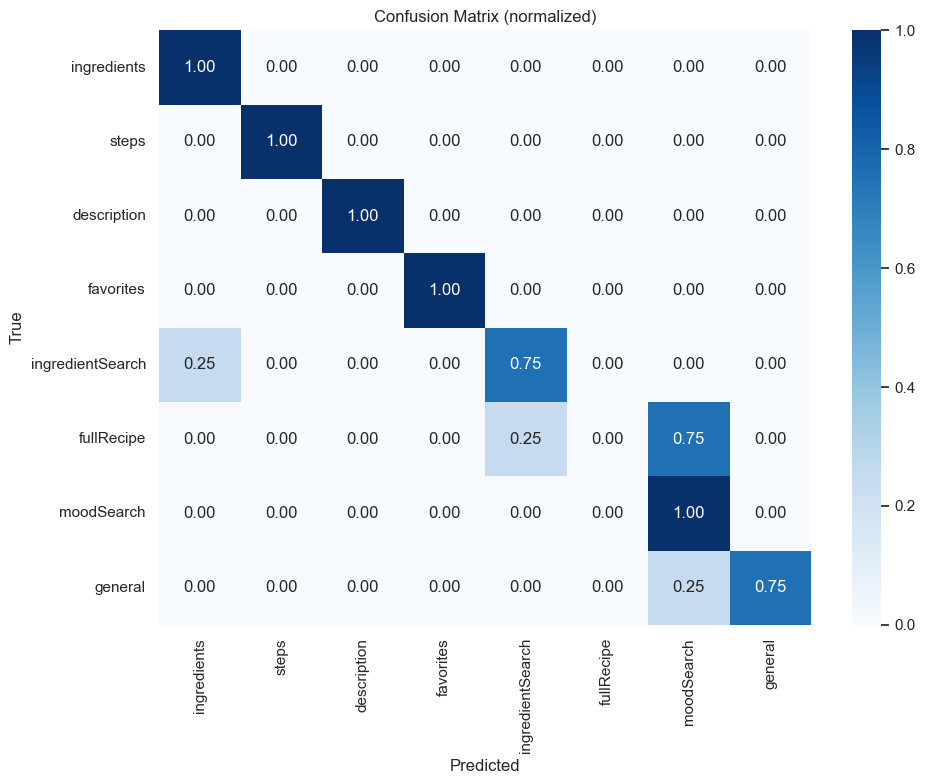

No per-class probability columns found; skip ROC/PR
No per-class probability columns found; cannot compute calibration.
Accuracy: 0.8125

Classification report:

                  precision    recall  f1-score   support

     ingredients       0.80      1.00      0.89         4
           steps       1.00      1.00      1.00         4
     description       1.00      1.00      1.00         4
       favorites       1.00      1.00      1.00         4
ingredientSearch       0.75      0.75      0.75         4
      fullRecipe       0.00      0.00      0.00         4
      moodSearch       0.50      1.00      0.67         4
         general       1.00      0.75      0.86         4

        accuracy                           0.81        32
       macro avg       0.76      0.81      0.77        32
    weighted avg       0.76      0.81      0.77        32



,label,precision,recall,f1,support
0,ingredients,0.80,1.00,0.888889,4
1,steps,1.00,1.00,1.000000,4
2,description,1.00,1.00,1.000000,4
3,favorites,1.00,1.00,1.000000,4
4,ingredientSearch,0.75,0.75,0.750000,4
5,fullRecipe,0.00,0.00,0.000000,4
6,moodSearch,0.50,1.00,0.666667,4
7,general,1.00,0.75,0.857143,4


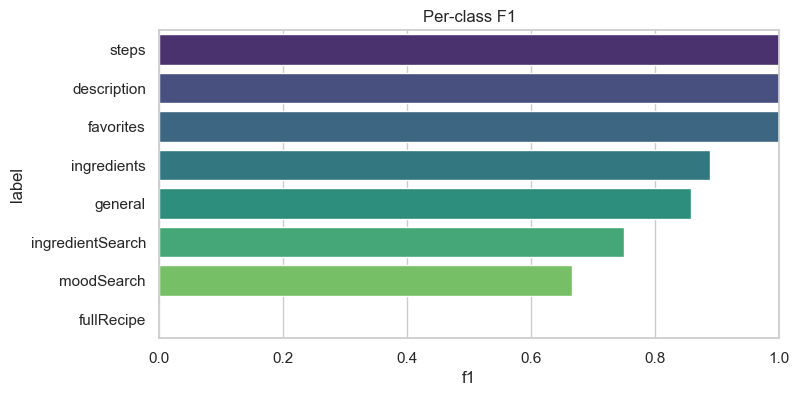


Top misclassifications for true label = ingredientSearch


,text,true_label,predicted_label
17,what can i make with egg and tomato,ingredientSearch,ingredients



Top misclassifications for true label = fullRecipe


,text,true_label,predicted_label
20,suggest a creamy soup dish,fullRecipe,moodSearch
21,recommend a spicy meal,fullRecipe,moodSearch
22,find me a sweet dessert recipe,fullRecipe,ingredientSearch
23,i need a healthy food idea,fullRecipe,moodSearch



Top misclassifications for true label = general


,text,true_label,predicted_label
30,good morning,general,moodSearch


Probability column not found: prob_fullRecipe
Probability column not found: prob_moodSearch


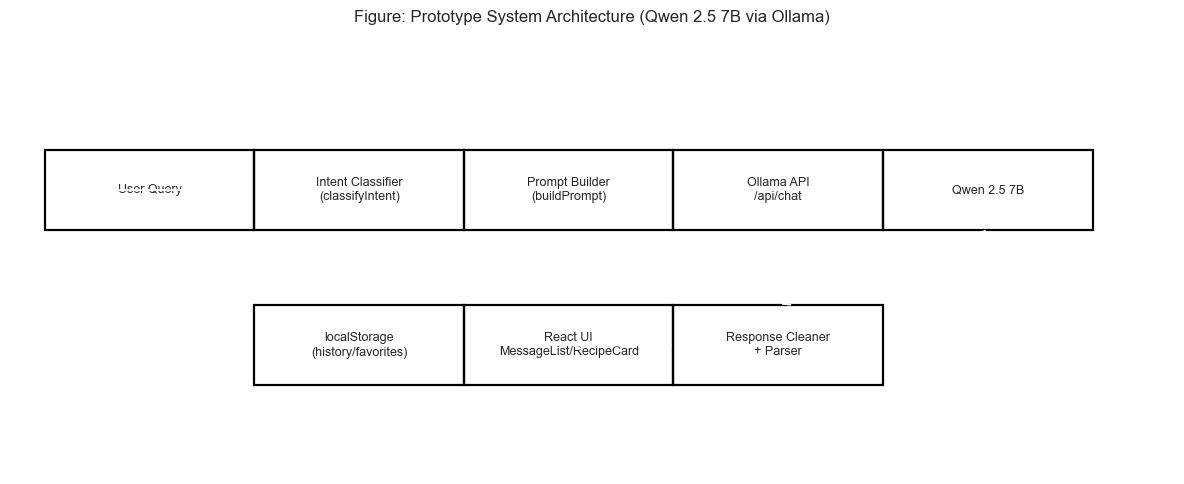

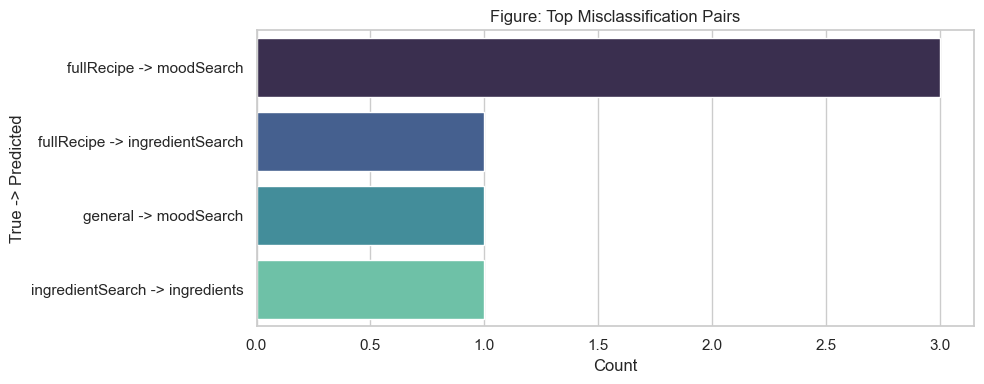

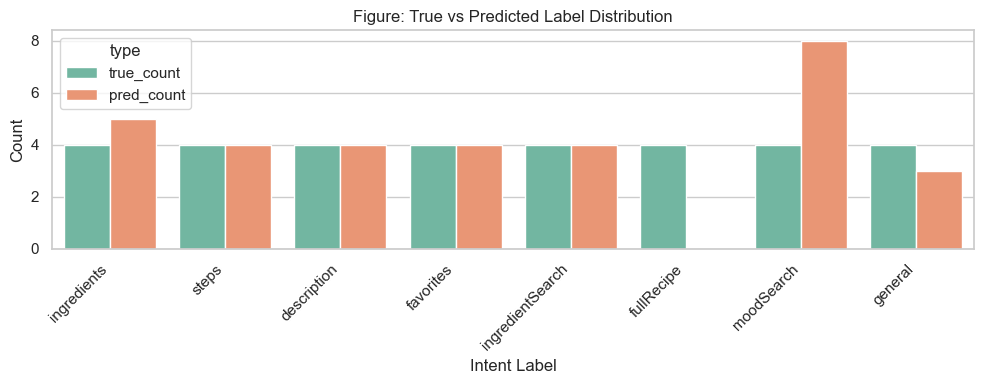

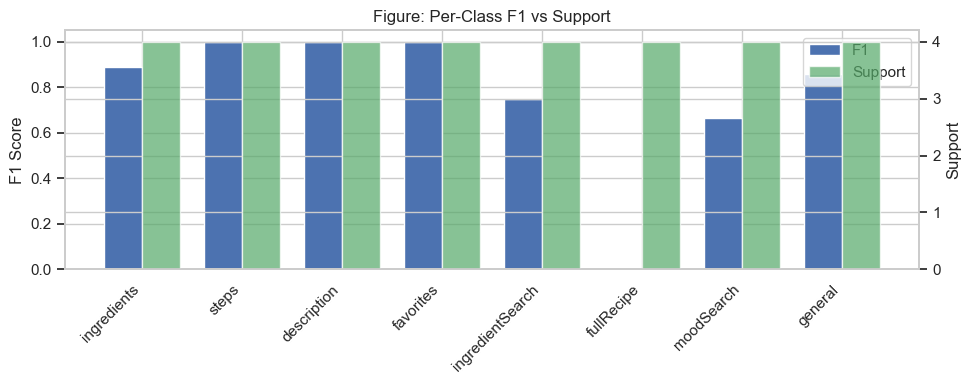

Latency summary (seconds):
mean = 3.131 | median = 2.757 | p95 = 3.118


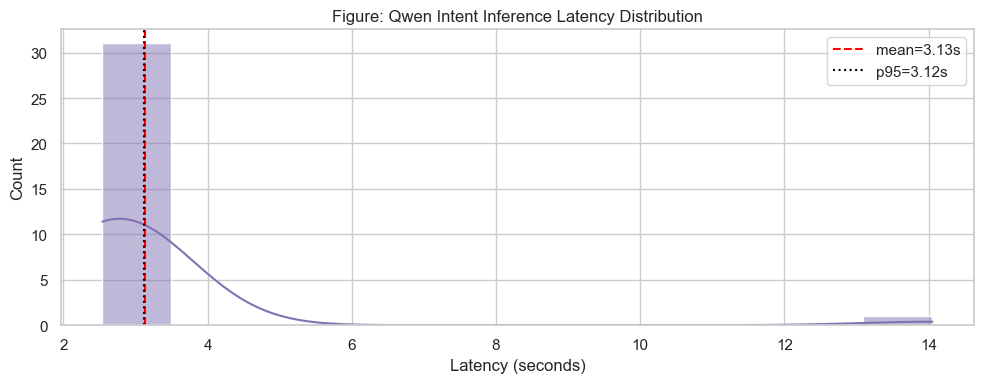

Top weaknesses (low F1):


,label,precision,recall,f1,support
5,fullRecipe,0.00,0.00,0.000000,4
6,moodSearch,0.50,1.00,0.666667,4
4,ingredientSearch,0.75,0.75,0.750000,4



Top strengths (high F1):


,label,precision,recall,f1,support
1,steps,1.0,1.0,1.0,4
2,description,1.0,1.0,1.0,4
3,favorites,1.0,1.0,1.0,4



Recommendations:
- Collect more labeled examples for the low-F1 intents, especially where support is low.
- Add targeted augmentation for short ambiguous queries ("description" vs "general").
- Use confidence thresholding for `moodSearch` and `fullRecipe` to avoid incorrect recommendations; fall back to clarifying question when below threshold.
- Monitor confusion pairs and add focused training data for the most frequent confusions.
- Consider a small rule-based post-filter to fix obvious mistakes (e.g., queries containing "ingredients" -> force `ingredients`).
Evaluation complete. Outputs shown directly in this notebook.


In [20]:
# Run full evaluation now (uses seed dataset automatically if no CSV path is provided)
evaluate()